In [250]:
#import sys
#!{sys.executable} -m pip install scikit-learn  

   ---------------------------------------- 0.0/8.0 MB ? eta -:--:--
   ------ --------------------------------- 1.3/8.0 MB 7.3 MB/s eta 0:00:01
   ------------- -------------------------- 2.6/8.0 MB 7.3 MB/s eta 0:00:01
   -------------------- ------------------- 4.2/8.0 MB 7.3 MB/s eta 0:00:01
   ---------------------------- ----------- 5.8/8.0 MB 7.3 MB/s eta 0:00:01
   ----------------------------------- ---- 7.1/8.0 MB 7.3 MB/s eta 0:00:01
   ---------------------------------------- 8.0/8.0 MB 7.2 MB/s  0:00:01
   ---------------------------------------- 0.0/36.5 MB ? eta -:--:--
   - -------------------------------------- 1.3/36.5 MB 7.2 MB/s eta 0:00:05
   --- ------------------------------------ 2.9/36.5 MB 7.1 MB/s eta 0:00:05
   ---- ----------------------------------- 4.2/36.5 MB 7.1 MB/s eta 0:00:05
   ------ --------------------------------- 5.8/36.5 MB 7.2 MB/s eta 0:00:05
   ------- -------------------------------- 7.1/36.5 MB 7.2 MB/s eta 0:00:05
   --------- ----------

In [ ]:
#components################################################################################

In [2]:
import requests
import urllib.parse as up
import pandas as pd
from pandas import json_normalize
import json
import glob
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import numpy as np
from sklearn.linear_model import LinearRegression

base = "https://luftdaten.umweltbundesamt.de/api/air-data/v4/components/json?lang=de&index=code" 
#query = {
    #"angebotsart": "1",
    #"wo": "Schleswig-Holstein",
    #"umkreis": "200",
    #"arbeitszeit": "ho;mj",  # Semikolon bleibt bewusst erhalten
    #"page": "5",
    #"size": "250",
    #"pav": "false",
#}
# safe=';' sorgt dafür, dass das Semikolon nicht encodiert wird, falls die API es so erwartet
url = f"{base}?{up.urlencode}"

#url = f"{base}?{up.urlencode(query, safe=';')}"

#headers = {
    #"X-API-Key": "jobboerse-jobsuche",
    #"Accept": "application/json",
    #"User-Agent": "Mozilla/5.0",
#}

r = requests.get(url, timeout=30)
print("URL:", r.url)
print("Status:", r.status_code, r.reason)
print("CT:", r.headers.get("content-type"))
data1= r.json()


URL: https://luftdaten.umweltbundesamt.de/api/air-data/v4/components/json?lang=de&index=code?%3Cfunction%20urlencode%20at%200x00000243339D2980%3E
Status: 200 OK
CT: application/json


In [3]:
print(data1.keys())

dict_keys(['count', 'indices', '1', '2', '3', '4', '5', '6', '7', '8', '9', '10', '11', '12'])


In [5]:
indices=data1["indices"] #alle möglichen Eigenschaften inklusive der dort vorhanden Daten denke ich mal für Angebotsart 1
indices                 #aus manchen Eigenschaften werde ich aber noch nicht so richtig schlau, da keine Einheiten gegeben sind

['component id',
 'component code',
 'component symbol',
 'component unit',
 'component name']

In [6]:
data1


{'count': 12,
 'indices': ['component id',
  'component code',
  'component symbol',
  'component unit',
  'component name'],
 '1': ['1', 'PM10', 'PM₁₀', 'µg/m³', 'Feinstaub'],
 '2': ['2', 'CO', 'CO', 'mg/m³', 'Kohlenmonoxid'],
 '3': ['3', 'O3', 'O₃', 'µg/m³', 'Ozon'],
 '4': ['4', 'SO2', 'SO₂', 'µg/m³', 'Schwefeldioxid'],
 '5': ['5', 'NO2', 'NO₂', 'µg/m³', 'Stickstoffdioxid'],
 '6': ['6', 'PM10PB', 'Pb', 'µg/m³', 'Blei im Feinstaub'],
 '7': ['7', 'PM10BAP', 'BaP', 'ng/m³', 'Benzo(a)pyren im Feinstaub'],
 '8': ['8', 'CHB', 'C₆H₆', 'µg/m³', 'Benzol'],
 '9': ['9', 'PM2', 'PM₂,₅', 'µg/m³', 'Feinstaub'],
 '10': ['10', 'PM10AS', 'As', 'ng/m³', 'Arsen im Feinstaub'],
 '11': ['11', 'PM10CD', 'Cd', 'ng/m³', 'Cadmium im Feinstaub'],
 '12': ['12', 'PM10NI', 'Ni', 'ng/m³', 'Nickel im Feinstaub']}

In [7]:
columns1 = data1["indices"]
columns1

['component id',
 'component code',
 'component symbol',
 'component unit',
 'component name']

In [8]:
rows1 = [value for key, value in data1.items() if key.isdigit()]
rows1

[['1', 'PM10', 'PM₁₀', 'µg/m³', 'Feinstaub'],
 ['2', 'CO', 'CO', 'mg/m³', 'Kohlenmonoxid'],
 ['3', 'O3', 'O₃', 'µg/m³', 'Ozon'],
 ['4', 'SO2', 'SO₂', 'µg/m³', 'Schwefeldioxid'],
 ['5', 'NO2', 'NO₂', 'µg/m³', 'Stickstoffdioxid'],
 ['6', 'PM10PB', 'Pb', 'µg/m³', 'Blei im Feinstaub'],
 ['7', 'PM10BAP', 'BaP', 'ng/m³', 'Benzo(a)pyren im Feinstaub'],
 ['8', 'CHB', 'C₆H₆', 'µg/m³', 'Benzol'],
 ['9', 'PM2', 'PM₂,₅', 'µg/m³', 'Feinstaub'],
 ['10', 'PM10AS', 'As', 'ng/m³', 'Arsen im Feinstaub'],
 ['11', 'PM10CD', 'Cd', 'ng/m³', 'Cadmium im Feinstaub'],
 ['12', 'PM10NI', 'Ni', 'ng/m³', 'Nickel im Feinstaub']]

In [9]:
df = pd.DataFrame(rows1, columns=columns1)
df

,component id,component code,component symbol,component unit,component name
0,1,PM10,PM₁₀,µg/m³,Feinstaub
1,2,CO,CO,mg/m³,Kohlenmonoxid
2,3,O3,O₃,µg/m³,Ozon
3,4,SO2,SO₂,µg/m³,Schwefeldioxid
4,5,NO2,NO₂,µg/m³,Stickstoffdioxid
5,6,PM10PB,Pb,µg/m³,Blei im Feinstaub
6,7,PM10BAP,BaP,ng/m³,Benzo(a)pyren im Feinstaub
7,8,CHB,C₆H₆,µg/m³,Benzol
8,9,PM2,"PM₂,₅",µg/m³,Feinstaub
9,10,PM10AS,As,ng/m³,Arsen im Feinstaub


In [10]:
#df.to_csv("get_all_components.csv", index=False)

In [11]:
#networks######################################################################################

In [12]:
url = "https://luftdaten.umweltbundesamt.de/api/air-data/v4/networks/json?lang=de"

r = requests.get(url, timeout=30)
print("URL:", r.url)
print("Status:", r.status_code, r.reason)
print("CT:", r.headers.get("content-type"))
data2= r.json()

URL: https://luftdaten.umweltbundesamt.de/api/air-data/v4/networks/json?lang=de
Status: 200 OK
CT: application/json


In [13]:
data2

{'indices': ['network id', 'network code', 'network name'],
 'data': {'1': ['1', 'BW', 'Baden-Württemberg'],
  '2': ['2', 'BY', 'Bayern'],
  '3': ['3', 'BE', 'Berlin'],
  '4': ['4', 'BB', 'Brandenburg'],
  '5': ['5', 'HB', 'Bremen'],
  '6': ['6', 'HH', 'Hamburg'],
  '7': ['7', 'HE', 'Hessen'],
  '8': ['8', 'MV', 'Mecklenburg-Vorpommern'],
  '9': ['9', 'NI', 'Niedersachsen'],
  '10': ['10', 'NW', 'Nordrhein-Westfalen'],
  '11': ['11', 'RP', 'Rheinland-Pfalz'],
  '12': ['12', 'SL', 'Saarland'],
  '13': ['13', 'SN', 'Sachsen'],
  '14': ['14', 'ST', 'Sachsen-Anhalt'],
  '15': ['15', 'SH', 'Schleswig-Holstein'],
  '16': ['16', 'TH', 'Thüringen'],
  '17': ['17', 'UB', 'UBA']},
 'count': 17}

In [14]:
columns2 = data2["indices"]
columns2

['network id', 'network code', 'network name']

In [15]:
rows2 = [value for key, value in data2["data"].items() if key.isdigit()]
rows2

[['1', 'BW', 'Baden-Württemberg'],
 ['2', 'BY', 'Bayern'],
 ['3', 'BE', 'Berlin'],
 ['4', 'BB', 'Brandenburg'],
 ['5', 'HB', 'Bremen'],
 ['6', 'HH', 'Hamburg'],
 ['7', 'HE', 'Hessen'],
 ['8', 'MV', 'Mecklenburg-Vorpommern'],
 ['9', 'NI', 'Niedersachsen'],
 ['10', 'NW', 'Nordrhein-Westfalen'],
 ['11', 'RP', 'Rheinland-Pfalz'],
 ['12', 'SL', 'Saarland'],
 ['13', 'SN', 'Sachsen'],
 ['14', 'ST', 'Sachsen-Anhalt'],
 ['15', 'SH', 'Schleswig-Holstein'],
 ['16', 'TH', 'Thüringen'],
 ['17', 'UB', 'UBA']]

In [16]:
df = pd.DataFrame(rows2, columns=columns2)
df

,network id,network code,network name
0,1,BW,Baden-Württemberg
1,2,BY,Bayern
2,3,BE,Berlin
3,4,BB,Brandenburg
4,5,HB,Bremen
5,6,HH,Hamburg
6,7,HE,Hessen
7,8,MV,Mecklenburg-Vorpommern
8,9,NI,Niedersachsen
9,10,NW,Nordrhein-Westfalen


In [17]:
#df.to_csv("get_all_networks.csv", index=False)

In [18]:
#Scopes######################################################################################

In [19]:
url = "https://luftdaten.umweltbundesamt.de/api/air-data/v4/scopes/json?lang=de" 

r = requests.get(url, timeout=30)
print("URL:", r.url)
print("Status:", r.status_code, r.reason)
print("CT:", r.headers.get("content-type"))
data3= r.json()

URL: https://luftdaten.umweltbundesamt.de/api/air-data/v4/scopes/json?lang=de
Status: 200 OK
CT: application/json


In [20]:
data3

{'count': 6,
 'indices': ['scope id',
  'scope code',
  'scope time base',
  'scope time scope',
  'scope time is max',
  'scope name'],
 '1': ['1', '1TMW', 'day', '86400', '0', 'Tagesmittel'],
 '2': ['2', '1SMW', 'hour', '3600', '0', 'Ein-Stunden-Mittelwert'],
 '3': ['3', '1SMW_MAX', 'hour', '3600', '1', 'Ein-Stunden-Tagesmaxima'],
 '4': ['4', '8SMW', 'hour', '28800', '0', 'Acht-Stunden-Mittelwert'],
 '5': ['5', '8SMW_MAX', 'hour', '28800', '1', 'Acht-Stunden-Tagesmaxima'],
 '6': ['6', '1TMWGL', 'hour', '3600', '0', 'Tagesmittel (stündlich gleitend)']}

In [21]:
columns3 = data3["indices"]
columns3

['scope id',
 'scope code',
 'scope time base',
 'scope time scope',
 'scope time is max',
 'scope name']

In [22]:
rows3 = [value for key, value in data3.items() if key.isdigit()]
rows3

[['1', '1TMW', 'day', '86400', '0', 'Tagesmittel'],
 ['2', '1SMW', 'hour', '3600', '0', 'Ein-Stunden-Mittelwert'],
 ['3', '1SMW_MAX', 'hour', '3600', '1', 'Ein-Stunden-Tagesmaxima'],
 ['4', '8SMW', 'hour', '28800', '0', 'Acht-Stunden-Mittelwert'],
 ['5', '8SMW_MAX', 'hour', '28800', '1', 'Acht-Stunden-Tagesmaxima'],
 ['6', '1TMWGL', 'hour', '3600', '0', 'Tagesmittel (stündlich gleitend)']]

In [23]:
df = pd.DataFrame(rows3, columns=columns3)
df

,scope id,scope code,scope time base,scope time scope,scope time is max,scope name
0,1,1TMW,day,86400,0,Tagesmittel
1,2,1SMW,hour,3600,0,Ein-Stunden-Mittelwert
2,3,1SMW_MAX,hour,3600,1,Ein-Stunden-Tagesmaxima
3,4,8SMW,hour,28800,0,Acht-Stunden-Mittelwert
4,5,8SMW_MAX,hour,28800,1,Acht-Stunden-Tagesmaxima
5,6,1TMWGL,hour,3600,0,Tagesmittel (stündlich gleitend)


In [24]:
#df.to_csv("get_all_scopes.csv", index=False)

In [25]:
#threshholds#######################################################################################

In [101]:
url = "https://luftdaten.umweltbundesamt.de/api/air-data/v4/thresholds/json?use=airquality&component=5&scope=2"

r = requests.get(url, timeout=30)
print("URL:", r.url)
print("Status:", r.status_code, r.reason)
print("CT:", r.headers.get("content-type"))
data4= r.json()

URL: https://luftdaten.umweltbundesamt.de/api/air-data/v4/thresholds/json?use=airquality&component=5&scope=2
Status: 200 OK
CT: application/json


In [102]:
data4

{'count': 5,
 'indices': ['threshold id',
  'component id',
  'scope id',
  'threshold type',
  'threshold min',
  'threshold max',
  'threshold index'],
 '201': ['201', '5', '2', 'aq4', '0', '10', '0'],
 '202': ['202', '5', '2', 'aq4', '11', '30', '1'],
 '203': ['203', '5', '2', 'aq4', '31', '60', '2'],
 '204': ['204', '5', '2', 'aq4', '61', '100', '3'],
 '205': ['205', '5', '2', 'aq4', '101', '2000', '4']}

In [103]:
columns4 = data4["indices"]
columns4

['threshold id',
 'component id',
 'scope id',
 'threshold type',
 'threshold min',
 'threshold max',
 'threshold index']

In [104]:
rows4 = [value for key, value in data4.items() if key.isdigit()]
rows4

[['201', '5', '2', 'aq4', '0', '10', '0'],
 ['202', '5', '2', 'aq4', '11', '30', '1'],
 ['203', '5', '2', 'aq4', '31', '60', '2'],
 ['204', '5', '2', 'aq4', '61', '100', '3'],
 ['205', '5', '2', 'aq4', '101', '2000', '4']]

In [105]:
df = pd.DataFrame(rows4, columns=columns4)
df

,threshold id,component id,scope id,threshold type,threshold min,threshold max,threshold index
0,201,5,2,aq4,0,10,0
1,202,5,2,aq4,11,30,1
2,203,5,2,aq4,31,60,2
3,204,5,2,aq4,61,100,3
4,205,5,2,aq4,101,2000,4


In [31]:
#df.to_csv("get_specific_threshold_(not all).csv", index=False)

In [32]:
#get all stations##########################################################################

In [99]:
url = "https://luftdaten.umweltbundesamt.de/api/air-data/v4/stations/json?use=airquality&lang=de&date_from=2026-03-01&date_to=2026-03-01&time_from=9&time_to=9"

r = requests.get(url, timeout=30)
print("URL:", r.url)
print("Status:", r.status_code, r.reason)
print("CT:", r.headers.get("content-type"))
data5= r.json()

URL: https://luftdaten.umweltbundesamt.de/api/air-data/v4/stations/json?use=airquality&lang=de&date_from=2026-03-01&date_to=2026-03-01&time_from=9&time_to=9
Status: 200 OK
CT: application/json


In [100]:
data5

{'request': {'use': 'airquality',
  'date_from': '2026-03-01',
  'date_to': '2026-03-01',
  'time_from': '09:00:00',
  'time_to': '09:00:00',
  'lang': 'de',
  'recent': False,
  'index': 'id',
  'datetime_from': '2026-03-01 08:00:00',
  'datetime_to': '2026-03-01 08:00:00'},
 'indices': ['station id',
  'station code',
  'station name',
  'station city',
  'station synonym',
  'station active from',
  'station active to',
  'station longitude',
  'station latitude',
  'network id',
  'station setting id',
  'station type id',
  'network code',
  'network name',
  'station setting name',
  'station setting short name',
  'station type name',
  'station street',
  'station street nr',
  'station zip code'],
 'data': {'21': ['21',
   'DEBB021',
   'Potsdam-Zentrum',
   'Potsdam',
   'PDBA',
   '2009-04-15',
   None,
   '13.0602',
   '52.4014',
   '4',
   '1',
   '1',
   'BB',
   'Brandenburg',
   'städtisches Gebiet',
   'städtisch',
   'Hintergrund',
   'Am Bassinplatz',
   '',
   '1446

In [101]:
columns5 = data5["indices"]
columns5

['station id',
 'station code',
 'station name',
 'station city',
 'station synonym',
 'station active from',
 'station active to',
 'station longitude',
 'station latitude',
 'network id',
 'station setting id',
 'station type id',
 'network code',
 'network name',
 'station setting name',
 'station setting short name',
 'station type name',
 'station street',
 'station street nr',
 'station zip code']

In [102]:
rows5 = [value for key, value in data5["data"].items() if key.isdigit()]
rows5

[['21',
  'DEBB021',
  'Potsdam-Zentrum',
  'Potsdam',
  'PDBA',
  '2009-04-15',
  None,
  '13.0602',
  '52.4014',
  '4',
  '1',
  '1',
  'BB',
  'Brandenburg',
  'städtisches Gebiet',
  'städtisch',
  'Hintergrund',
  'Am Bassinplatz',
  '',
  '14467'],
 ['28',
  'DEBB029',
  'Schwedt (Oder)',
  'Schwedt/Oder',
  'SWHE',
  '1993-04-06',
  None,
  '14.2851',
  '53.0643',
  '4',
  '2',
  '2',
  'BB',
  'Brandenburg',
  'vorstädtisches Gebiet',
  'vorstädtisch',
  'Industrie',
  'Helbigstr.',
  '',
  '16303'],
 ['31',
  'DEBB032',
  'Eisenhüttenstadt',
  'Eisenhüttenstadt',
  'EHST',
  '1993-04-20',
  None,
  '14.6382',
  '52.1463',
  '4',
  '2',
  '2',
  'BB',
  'Brandenburg',
  'vorstädtisches Gebiet',
  'vorstädtisch',
  'Industrie',
  'Karl-Marx-Str.',
  '35',
  '15890'],
 ['42',
  'DEBB044',
  'Cottbus, Bahnhofstr.',
  'Cottbus',
  'COBA',
  '2012-09-25',
  None,
  '14.3280',
  '51.7566',
  '4',
  '1',
  '3',
  'BB',
  'Brandenburg',
  'städtisches Gebiet',
  'städtisch',
  'Verkehr

In [98]:
df = pd.DataFrame(rows5, columns=columns5)
df

,station id,station code,station name,station city,station synonym,station active from,station active to,station longitude,station latitude,network id,station setting id,station type id,network code,network name,station setting name,station setting short name,station type name,station street,station street nr,station zip code
0,21,DEBB021,Potsdam-Zentrum,Potsdam,PDBA,2009-04-15,NaN,13.0602,52.4014,4,1,1,BB,Brandenburg,städtisches Gebiet,städtisch,Hintergrund,Am Bassinplatz,,14467
1,28,DEBB029,Schwedt (Oder),Schwedt/Oder,SWHE,1993-04-06,NaN,14.2851,53.0643,4,2,2,BB,Brandenburg,vorstädtisches Gebiet,vorstädtisch,Industrie,Helbigstr.,,16303
2,31,DEBB032,Eisenhüttenstadt,Eisenhüttenstadt,EHST,1993-04-20,NaN,14.6382,52.1463,4,2,2,BB,Brandenburg,vorstädtisches Gebiet,vorstädtisch,Industrie,Karl-Marx-Str.,35,15890
3,42,DEBB044,"Cottbus, Bahnhofstr.",Cottbus,COBA,2012-09-25,NaN,14.3280,51.7566,4,1,3,BB,Brandenburg,städtisches Gebiet,städtisch,Verkehr,Bahnhofstr.,55,03046
4,43,DEBB045,"Frankfurt (Oder), Leipziger Str.",Frankfurt (Oder),FFLS,1995-08-01,NaN,14.5386,52.3373,4,1,3,BB,Brandenburg,städtisches Gebiet,städtisch,Verkehr,Leipziger Str.,,15232
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
422,1679,DESN091,Zwickau-Werdauer Str.,Zwickau,ZwickauW,2011-10-20,NaN,12.4866,50.7204,13,1,3,SN,Sachsen,städtisches Gebiet,städtisch,Verkehr,Werdauer Str./Crimmitschauer Str.,,08056
423,10351,DESH062,Norderstedt Bekwisch,Norderstedt,,2024-01-01,NaN,9.9906,53.6760,15,1,1,SH,Schleswig-Holstein,städtisches Gebiet,städtisch,Hintergrund,Bekwisch,9,22848
424,10388,DEST144,Magdeburg City-Tunnel,Magdeburg,,2024-01-01,NaN,11.6306,52.1312,14,1,3,ST,Sachsen-Anhalt,städtisches Gebiet,städtisch,Verkehr,Ernst-Reuter-Allee,,39104
425,9566,DEBW245,Pforzheim Luisenstraße,Pforzheim,,2026-01-01,NaN,8.6962,48.8937,1,1,3,BW,Baden-Württemberg,städtisches Gebiet,städtisch,Verkehr,Luisenstraße,18,75172


In [103]:
#df.to_csv("get_all_stations.csv", index=False)

In [137]:
df_filter = df[df["network name"] == "UBA"]
df_filter

,station id,station code,station name,station city,station synonym,station active from,station active to,station longitude,station latitude,network id,station setting id,station type id,network code,network name,station setting name,station setting short name,station type name,station street,station street nr,station zip code
326,1945,DEUB001,Westerland,Westerland,,1968-01-01,NaN,8.3080,54.9231,17,3,1,UB,UBA,ländliches Gebiet,ländlich,Hintergrund,Lornsenweg,9,25980
327,1948,DEUB004,Schauinsland,Oberried-Hofsgrund,,1968-01-01,NaN,7.9040,47.9129,17,5,1,UB,UBA,ländlich regional,ländlich,Hintergrund,Schauinslandstr.,2,79254
328,1949,DEUB005,Waldhof,Lüder-Langenbrügge,,1970-01-01,NaN,10.7561,52.8009,17,3,1,UB,UBA,ländliches Gebiet,ländlich,Hintergrund,Waldhof,1,29394
329,1972,DEUB028,Zingst,Zingst,,1991-09-01,NaN,12.7250,54.4368,17,3,1,UB,UBA,ländliches Gebiet,ländlich,Hintergrund,Landstr.,3,18374
330,1973,DEUB029,Schmücke,Gehlberg,,1978-07-01,NaN,10.7694,50.6546,17,3,1,UB,UBA,ländliches Gebiet,ländlich,Hintergrund,Schmücke,,98559
331,1974,DEUB030,Neuglobsow,Neuglobsow,,1969-01-01,NaN,13.0323,53.1423,17,5,1,UB,UBA,ländlich regional,ländlich,Hintergrund,Zur alten Fischerhütte,1,16775
332,1988,DEUB044,Zugspitze Schneefernerhaus,Zugspitze,,1999-06-01,NaN,10.9807,47.4144,17,4,1,UB,UBA,ländlich abgelegen,ländlich,Hintergrund,Zugspitze,5,82475


In [138]:
#df_filter.to_csv("stationen-UBA.csv", index=False)

In [ ]:
#Station 21 Datenabfrage Versuch############################################################

In [40]:
url = "https://luftdaten.umweltbundesamt.de/api/air-data/v4/measures/json?date_from=2024-09-01&time_from=9&date_to=2025-09-01&time_to=9&station=21&component=1&scope=1"

r = requests.get(url, timeout=30)
print("URL:", r.url)
print("Status:", r.status_code, r.reason)
print("CT:", r.headers.get("content-type"))
data6= r.json()

URL: https://luftdaten.umweltbundesamt.de/api/air-data/v4/measures/json?date_from=2024-09-01&time_from=9&date_to=2025-09-01&time_to=9&station=21&component=1&scope=1
Status: 200 OK
CT: application/json


In [41]:
data6

{'request': {'component': '1',
  'scope': '1',
  'station': '21',
  'date_from': '2024-09-01',
  'date_to': '2025-09-01',
  'time_from': '09:00:00',
  'time_to': '09:00:00',
  'recent': False,
  'index': 'id',
  'lang': 'en',
  'datetime_from': '2024-09-01 08:00:00',
  'datetime_to': '2025-09-01 08:00:00'},
 'indices': {'data': {'station id': {'date start': ['component id',
     'scope id',
     'value',
     'date end',
     'index']}}},
 'data': {'21': {'2024-09-01 11:00:00': [1, 1, 16, '2024-09-01 12:00:00', '3'],
   '2024-09-02 11:00:00': [1, 1, 19, '2024-09-02 12:00:00', '3'],
   '2024-09-03 11:00:00': [1, 1, 35, '2024-09-03 12:00:00', '6'],
   '2024-09-04 11:00:00': [1, 1, 38, '2024-09-04 12:00:00', '7'],
   '2024-09-05 11:00:00': [1, 1, 55, '2024-09-05 12:00:00', '10'],
   '2024-09-06 11:00:00': [1, 1, 54, '2024-09-06 12:00:00', '10'],
   '2024-09-07 11:00:00': [1, 1, 49, '2024-09-07 12:00:00', '9'],
   '2024-09-08 11:00:00': [1, 1, 31, '2024-09-08 12:00:00', '6'],
   '2024-09-0

In [42]:
columns6 = data6["indices"]
columns6

{'data': {'station id': {'date start': ['component id',
    'scope id',
    'value',
    'date end',
    'index']}}}

In [43]:
rows6 = [value for key, value in data6["data"].items() if key.isdigit()]
rows6

[{'2024-09-01 11:00:00': [1, 1, 16, '2024-09-01 12:00:00', '3'],
  '2024-09-02 11:00:00': [1, 1, 19, '2024-09-02 12:00:00', '3'],
  '2024-09-03 11:00:00': [1, 1, 35, '2024-09-03 12:00:00', '6'],
  '2024-09-04 11:00:00': [1, 1, 38, '2024-09-04 12:00:00', '7'],
  '2024-09-05 11:00:00': [1, 1, 55, '2024-09-05 12:00:00', '10'],
  '2024-09-06 11:00:00': [1, 1, 54, '2024-09-06 12:00:00', '10'],
  '2024-09-07 11:00:00': [1, 1, 49, '2024-09-07 12:00:00', '9'],
  '2024-09-08 11:00:00': [1, 1, 31, '2024-09-08 12:00:00', '6'],
  '2024-09-09 11:00:00': [1, 1, 10, '2024-09-09 12:00:00', '1'],
  '2024-09-10 11:00:00': [1, 1, 10, '2024-09-10 12:00:00', '1'],
  '2024-09-11 11:00:00': [1, 1, 7, '2024-09-11 12:00:00', '1'],
  '2024-09-12 11:00:00': [1, 1, 6, '2024-09-12 12:00:00', '1'],
  '2024-09-13 11:00:00': [1, 1, 7, '2024-09-13 12:00:00', '1'],
  '2024-09-14 11:00:00': [1, 1, 7, '2024-09-14 12:00:00', '1'],
  '2024-09-15 11:00:00': [1, 1, 6, '2024-09-15 12:00:00', '1'],
  '2024-09-16 11:00:00': [1,

In [58]:
rows = []

for station_id, station_data in data6["data"].items():
    for date_start, values in station_data.items():
        rows.append(
            [station_id, date_start] + values
        )

df = pd.DataFrame(rows, columns=[
    "station id",
    "date start",
    "component id",
    "scope id",
    "value",
    "date end",
    "index"
])

df

,station id,date start,component id,scope id,value,date end,index
0,21,2024-09-01 11:00:00,1,1,16,2024-09-01 12:00:00,3
1,21,2024-09-02 11:00:00,1,1,19,2024-09-02 12:00:00,3
2,21,2024-09-03 11:00:00,1,1,35,2024-09-03 12:00:00,6
3,21,2024-09-04 11:00:00,1,1,38,2024-09-04 12:00:00,7
4,21,2024-09-05 11:00:00,1,1,55,2024-09-05 12:00:00,10
...,...,...,...,...,...,...,...
360,21,2025-08-27 11:00:00,1,1,22,2025-08-27 12:00:00,4
361,21,2025-08-28 11:00:00,1,1,18,2025-08-28 12:00:00,3
362,21,2025-08-29 11:00:00,1,1,15,2025-08-29 12:00:00,2
363,21,2025-08-30 11:00:00,1,1,12,2025-08-30 12:00:00,2


In [ ]:
#alle Stationen in Brandenburg abfragen für ein Jahr#########################################

In [173]:
station_ids = [21, 28, 31, 42, 43, 46, 47, 51, 52, 53, 61, 62, 63, 64, 65, 66, 71, 73, 81, 84, 90, 2113, 9535, 9568, 10465, 10469]
results=[]
base_url = "https://luftdaten.umweltbundesamt.de/api/air-data/v4/measures/json"

params = {
    "date_from": "2025-01-01",
    "time_from": "9",
    "date_to": "2026-01-01",
    "time_to": "9",
    "component": "1",
    "scope": "1"
}

for station in station_ids:
    params["station"] = station
    r = requests.get(base_url, params=params, timeout=30)
    data = r.json()
    results.append(data) 


print("URL:", r.url)
print("Status:", r.status_code, r.reason)
print("CT:", r.headers.get("content-type"))


URL: https://luftdaten.umweltbundesamt.de/api/air-data/v4/measures/json?date_from=2025-01-01&time_from=9&date_to=2026-01-01&time_to=9&component=1&scope=1&station=9595
Status: 200 OK
CT: application/json


In [174]:
results

[{'request': {'component': '1',
   'scope': '1',
   'station': '1057',
   'date_from': '2025-01-01',
   'date_to': '2026-01-01',
   'time_from': '09:00:00',
   'time_to': '09:00:00',
   'recent': False,
   'index': 'id',
   'lang': 'en',
   'datetime_from': '2025-01-01 08:00:00',
   'datetime_to': '2026-01-01 08:00:00'},
  'indices': {'data': {'station id': {'date start': ['component id',
      'scope id',
      'value',
      'date end',
      'index']}}},
  'data': {'1057': {'2025-01-01 11:00:00': [1,
     1,
     12,
     '2025-01-01 12:00:00',
     '2'],
    '2025-01-02 11:00:00': [1, 1, 10, '2025-01-02 12:00:00', '1'],
    '2025-01-03 11:00:00': [1, 1, 10, '2025-01-03 12:00:00', '1'],
    '2025-01-04 11:00:00': [1, 1, 20, '2025-01-04 12:00:00', '3'],
    '2025-01-05 11:00:00': [1, 1, 8, '2025-01-05 12:00:00', '1'],
    '2025-01-06 11:00:00': [1, 1, None, '2025-01-06 12:00:00', None],
    '2025-01-07 11:00:00': [1, 1, None, '2025-01-07 12:00:00', None],
    '2025-01-08 11:00:00': [

In [175]:
rows = []

for result in results:   # ← über jede API-Antwort
    for station_id, station_data in result["data"].items():
        for date_start, values in station_data.items():
            rows.append(
                [station_id, date_start] + values
            )

df = pd.DataFrame(rows, columns=[
    "station id",
    "date start",
    "component id",
    "scope id",
    "value",
    "date end",
    "index"
])

df

,station id,date start,component id,scope id,value,date end,index
0,1057,2025-01-01 11:00:00,1,1,12.0,2025-01-01 12:00:00,2
1,1057,2025-01-02 11:00:00,1,1,10.0,2025-01-02 12:00:00,1
2,1057,2025-01-03 11:00:00,1,1,10.0,2025-01-03 12:00:00,1
3,1057,2025-01-04 11:00:00,1,1,20.0,2025-01-04 12:00:00,3
4,1057,2025-01-05 11:00:00,1,1,8.0,2025-01-05 12:00:00,1
...,...,...,...,...,...,...,...
20649,9595,2025-12-27 11:00:00,1,1,21.0,2025-12-27 12:00:00,4
20650,9595,2025-12-28 11:00:00,1,1,18.0,2025-12-28 12:00:00,3
20651,9595,2025-12-29 11:00:00,1,1,18.0,2025-12-29 12:00:00,3
20652,9595,2025-12-30 11:00:00,1,1,14.0,2025-12-30 12:00:00,2


In [77]:
#df.to_csv("stationen_brandenburg_1_jahr__.csv", index=False)

In [ ]:
#Abfrage für Daten im Zeitfenster 1.1.2016 bis 1.1.2026#####################################

In [109]:
station_ids =[28, 31, 216, 231, 937, 1113, 1161, 1730, 1777]
results=[]
base_url = "https://luftdaten.umweltbundesamt.de/api/air-data/v4/measures/json"

params = {
    "date_from": "2016-01-01",
    "time_from": "9",
    "date_to": "2026-03-01",
    "time_to": "9",
    "component": "1",
    "scope": "1"
}

#5,9

for station in station_ids:
    params["station"] = station
    r = requests.get(base_url, params=params, timeout=30)
    data = r.json()
    results.append(data) 


print("URL:", r.url)
print("Status:", r.status_code, r.reason)
print("CT:", r.headers.get("content-type"))


URL: https://luftdaten.umweltbundesamt.de/api/air-data/v4/measures/json?date_from=2016-01-01&time_from=9&date_to=2026-03-01&time_to=9&component=1&scope=1&station=1777
Status: 200 OK
CT: application/json


In [103]:
#results

In [110]:
rows = []

for result in results:
    for station_id, station_data in result["data"].items():
        for date_start, values in station_data.items():
            rows.append(
                [station_id, date_start] + values
            )

df = pd.DataFrame(rows, columns=[
    "station id",
    "date start",
    "component id",
    "scope id",
    "value",
    "date end",
    "index"
])

df

,station id,date start,component id,scope id,value,date end,index
0,28,2016-01-01 11:00:00,1,1,48.0,2016-01-01 12:00:00,9
1,28,2016-01-02 11:00:00,1,1,43.0,2016-01-02 12:00:00,8
2,28,2016-01-03 11:00:00,1,1,37.0,2016-01-03 12:00:00,7
3,28,2016-01-04 11:00:00,1,1,56.0,2016-01-04 12:00:00,10
4,28,2016-01-05 11:00:00,1,1,69.0,2016-01-05 12:00:00,10
...,...,...,...,...,...,...,...
31942,1777,2026-02-24 11:00:00,1,1,11.0,2026-02-24 12:00:00,2
31943,1777,2026-02-25 11:00:00,1,1,12.0,2026-02-25 12:00:00,2
31944,1777,2026-02-26 11:00:00,1,1,8.0,2026-02-26 12:00:00,1
31945,1777,2026-02-27 11:00:00,1,1,16.0,2026-02-27 12:00:00,3


In [111]:
#df.to_csv("vorstädtisch_industrie_PM10.csv", index=False)

In [ ]:
#nur für Komponenten, die Stündlich gemessen werden: zB NO2 hat nur stündliche und keine tegesbezogenen Werte

In [220]:
df["date start"] = pd.to_datetime(df["date start"])

daily_avg = (
    df
    .groupby([
        "station id",
        "component id",
        "scope id",
        df["date start"].dt.date
    ])["value"]
    .mean()
    .reset_index()
)

daily_avg.rename(columns={"date start": "date"}, inplace=True)

daily_avg["date start"] = pd.to_datetime(daily_avg["date"]) + pd.Timedelta(hours=11)
daily_avg["date end"]   = pd.to_datetime(daily_avg["date"]) + pd.Timedelta(hours=12)

daily_avg.drop(columns="date", inplace=True)

daily_avg = daily_avg[
    [
        "station id",
        "date start",
        "component id",
        "scope id",
        "value",
        "date end"
    ]
]

daily_avg

,station id,date start,component id,scope id,value,date end
0,1945,2016-01-01 11:00:00,5,2,9.240000,2016-01-01 12:00:00
1,1945,2016-01-02 11:00:00,5,2,5.695652,2016-01-02 12:00:00
2,1945,2016-01-03 11:00:00,5,2,5.291667,2016-01-03 12:00:00
3,1945,2016-01-04 11:00:00,5,2,6.304348,2016-01-04 12:00:00
4,1945,2016-01-05 11:00:00,5,2,5.478261,2016-01-05 12:00:00
...,...,...,...,...,...,...
23570,1988,2025-07-19 11:00:00,5,2,NaN,2025-07-19 12:00:00
23571,1988,2025-07-20 11:00:00,5,2,NaN,2025-07-20 12:00:00
23572,1988,2025-07-21 11:00:00,5,2,NaN,2025-07-21 12:00:00
23573,1988,2025-07-22 11:00:00,5,2,NaN,2025-07-22 12:00:00


In [221]:
#daily_avg.to_csv("UBA_NO2.csv", index=False)

In [ ]:
#alle csv zusammenführen##################################################################

In [230]:
files = glob.glob(r"C:\Users\Anwender\arxiv_tutorial\arxiv_tutorial\DS\Datensatzarbeit(Air-Quality)\stationen_1.1.2016-1.3.2026_PM10/*csv")

dfs = []

for file in files:
    df = pd.read_csv(file)
    dfs.append(df)

df_all = pd.concat(dfs, ignore_index=True)

In [231]:
df_all["date start"] = pd.to_datetime(df_all["date start"])

In [232]:
df_all = df_all.dropna(subset=["value"])

In [233]:
#df_all.to_csv("deutschland_PM10.csv", index=False)

In [234]:
daily_avg = df_all.groupby("date start")["value"].mean().reset_index()

In [235]:
#daily_avg.to_csv("daily_avg_deutschland_PM10.csv", index=False)

In [236]:
monthly_avg = (
    daily_avg
    .groupby(daily_avg["date start"].dt.to_period("M"))["value"]
    .mean()
    .reset_index()
)

In [237]:
#monthly_avg.to_csv("monthly_avg_deutschland_PM10.csv", index=False)

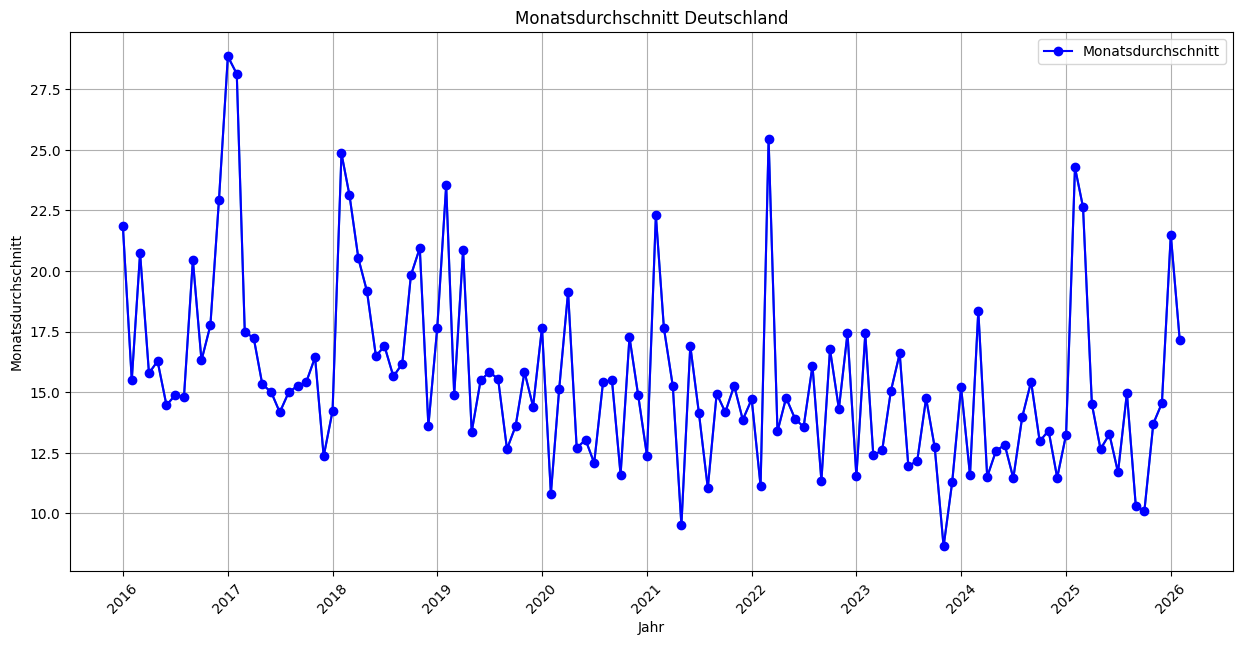

In [267]:
plt.figure(figsize=(15,7))
plt.plot(monthly_avg["date start"], monthly_avg["value"])
plt.plot(monthly_avg['date start'], monthly_avg['value'], label='Monatsdurchschnitt', marker='o', color='blue')

ax = plt.gca()


ax.xaxis.set_major_locator(mdates.YearLocator(1))  
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))


plt.grid()
plt.xticks(rotation=45)
plt.xlabel("Jahr")
plt.ylabel("Monatsdurchschnitt")
plt.title("Monatsdurchschnitt Deutschland")
plt.legend()
plt.show()

In [ ]:
#Regressionsgerade##########################################################################

In [258]:
monthly_avg = pd.read_csv(r"C:\Users\Anwender\arxiv_tutorial\arxiv_tutorial\DS\Test für Air Quality\monthly_avg_deutschland_PM10.csv", parse_dates=["date start"])

monthly_avg['days_since_start'] = (monthly_avg['date start'] - monthly_avg['date start'].min()).dt.days

X = monthly_avg['days_since_start'].values.reshape(-1, 1)
y = monthly_avg['value'].values

In [259]:
model = LinearRegression()
model.fit(X, y)

y_pred = model.predict(X)

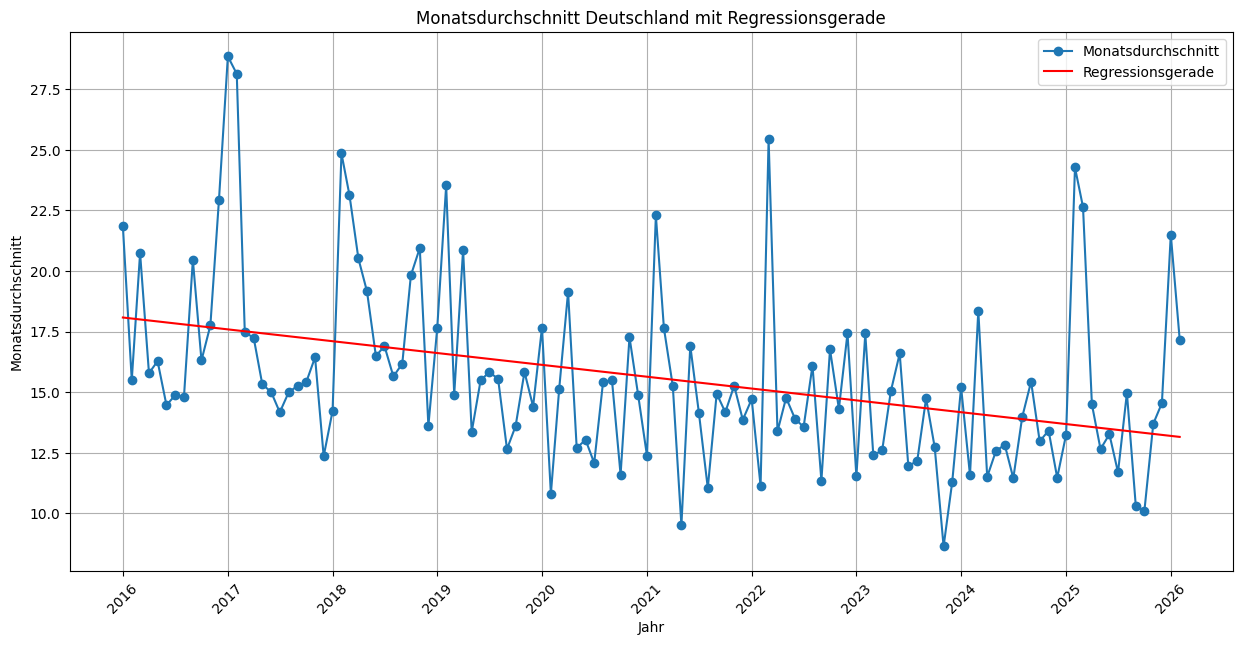

In [260]:
plt.figure(figsize=(15,7))

plt.plot(monthly_avg['date start'], monthly_avg['value'], label='Monatsdurchschnitt', marker='o')
plt.plot(monthly_avg['date start'], y_pred, color='red', label='Regressionsgerade')


ax = plt.gca()
ax.xaxis.set_major_locator(mdates.YearLocator(1))
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))

plt.grid(True)
plt.xticks(rotation=45)
plt.xlabel("Jahr")
plt.ylabel("Monatsdurchschnitt")
plt.title("Monatsdurchschnitt Deutschland mit Regressionsgerade")
plt.legend()
plt.show()

In [ ]:
#1.1 Corona#############################################################################

In [19]:
df = pd.read_csv(r"C:\Users\Anwender\arxiv_tutorial\arxiv_tutorial\DS\Datensatzarbeit(Air-Quality)\1 ergebisse\daily_avg_deutschland_PM2,5.csv")
corona_filter = df[(df["date start"] >="2019-01-01") & (df["date start"]<= "2022-01-01")]
corona_filter                     

,date start,value
1096,2019-01-01 11:00:00,21.324607
1097,2019-01-02 11:00:00,5.654450
1098,2019-01-03 11:00:00,8.382979
1099,2019-01-04 11:00:00,11.591623
1100,2019-01-05 11:00:00,6.031414
...,...,...
2187,2021-12-27 11:00:00,16.714286
2188,2021-12-28 11:00:00,13.359684
2189,2021-12-29 11:00:00,9.182540
2190,2021-12-30 11:00:00,4.730924


In [20]:
#corona_filter.to_csv("corona_PM2,5.csv", index=False)

In [ ]:
#1.2 Neujahre UND 5 seasons_PM10 ##############################################################################

In [9]:
df = pd.read_csv(r"C:\Users\Anwender\arxiv_tutorial\arxiv_tutorial\DS\Datensatzarbeit(Air-Quality)\1 ergebisse\daily_avg_deutschland_PM10.csv")
df["date start"] = pd.to_datetime(df["date start"])
neujahr_filter = df[
    (df["date start"].dt.month == 12) & (df["date start"].dt.day >= 1)
    |
    (df["date start"].dt.month == 1) & (df["date start"].dt.day <= 31)
]
neujahr_filter

,date start,value
31,2016-02-01 11:00:00,8.707463
32,2016-02-02 11:00:00,8.053731
33,2016-02-03 11:00:00,11.184524
34,2016-02-04 11:00:00,9.852071
35,2016-02-05 11:00:00,13.867257
...,...,...
3707,2026-02-24 11:00:00,10.972299
3708,2026-02-25 11:00:00,13.393352
3709,2026-02-26 11:00:00,16.060942
3710,2026-02-27 11:00:00,20.774105


In [10]:
neujahr_filter.to_csv("neujahr_NO2.csv", index=False)

In [ ]:
#3.1 Urban vs. Ländlich ###################################################################

In [78]:
df = pd.read_csv(r"C:\Users\Anwender\arxiv_tutorial\arxiv_tutorial\DS\Datensatzarbeit(Air-Quality)\attribute\get_all_stations.csv")

SVL_filter = df[(df["station setting short name"] == "ländlich") & (df["station type name"] == "Industrie")]
SVL_filter = SVL_filter[["station id"]]
SVL_filter

,station id
98,628
177,952
203,1129
229,1372
230,1380


In [79]:
#SVL_filter.to_csv("ländlich_Industrie_IDs.csv", index=False)

In [ ]:
#3 Budneländervergleich ##################################################################

In [144]:
df = pd.read_csv(r"C:\Users\Anwender\arxiv_tutorial\arxiv_tutorial\DS\Datensatzarbeit(Air-Quality)\4.1 urban_ländlich_präziser_PM10\vorstädtisch_industrie_PM10.csv")
df["date start"] = pd.to_datetime(df["date start"])
df = df.dropna(subset=["value"])
daily_avg = df.groupby("date start")["value"].mean().reset_index()
daily_avg

,date start,value
0,2016-01-01 11:00:00,41.000000
1,2016-01-02 11:00:00,26.111111
2,2016-01-03 11:00:00,28.333333
3,2016-01-04 11:00:00,34.444444
4,2016-01-05 11:00:00,46.444444
...,...,...
3707,2026-02-24 11:00:00,9.666667
3708,2026-02-25 11:00:00,13.222222
3709,2026-02-26 11:00:00,15.444444
3710,2026-02-27 11:00:00,18.444444


In [145]:
#daily_avg.to_csv("daily_avg_vorstädtisch_industrie_PM10.csv", index=False)

In [146]:
monthly_avg = (
    daily_avg
    .groupby(daily_avg["date start"].dt.to_period("M"))["value"]
    .mean()
    .reset_index()
)

In [147]:
#monthly_avg.to_csv("monthly_avg_vorstädtisch_industrie_PM10.csv", index=False)

In [ ]:
#2 Hintergrund, Verkehr, Industrie############################################################